# GridTransformer diffusion validation

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from implied_volatility_diffusion import (
    DiffusionModel,
    ReverseDiffusion,
    SurfaceNormalizer,
    UnifiedGrid,
    GridTransformer,
    VPNoiseScheduler,
    check_iv_surface_arbitrage,
    repair_calendar_monotone,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "axes.grid": False})


def _select_device():
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = _select_device()
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CFG_DIR = REPO_ROOT / "config"
DATASET_ROOT = REPO_ROOT / "data" / "processed" / "forecasting_dataset"
CHECKPOINT_DIR = REPO_ROOT / "data" / "processed" / "checkpoints"
CHECKPOINT_PATH = CHECKPOINT_DIR / "diffusion_grid_transformer.pt"
CONFIG_PATH = CHECKPOINT_DIR / "training_config.json"

GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")

if not (DATASET_ROOT / "manifest.json").exists():
    raise FileNotFoundError(
        f"missing {DATASET_ROOT / 'manifest.json'}; run notebooks/unified_surface_pipeline.ipynb first"
    )
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"missing {CHECKPOINT_PATH}; run notebooks/transformer-net-training.ipynb first")

print(f"compute device: {DEVICE}")
print(f"unified grid: {GRID.shape}")

compute device: mps
unified grid: (41, 40)


##  Validation Inputs

In [2]:
PATH_TYPES = ("historical", "sabr", "heston")
TENOR_SLICES_PER_SURFACE = 3
DDIM_STEPS = 200
MAX_GENERATION_TRIES = 16
ARB_DIAG_TOL = 1e-6
ARB_ACCEPT_TOL = 1e-4
GENERATED_ARB_TOL = ARB_ACCEPT_TOL
APPLY_CALENDAR_REPAIR = True
IV_FLOOR_SAMPLE = 1e-4
SAMPLER_CLIP_Z = (-4.0, 4.0)

SOURCE_LABELS = {0: "historical", 1: "heston", 2: "sabr"}
PATH_TYPE_TO_SRC_ID = {"historical": 0, "heston": 1, "sabr": 2}
unknown_paths = [p for p in PATH_TYPES if p not in PATH_TYPE_TO_SRC_ID]
if unknown_paths:
    raise ValueError(f"Unknown path types in PATH_TYPES: {unknown_paths}")

run_config = json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}
VALIDATION_SEED = int(run_config.get("seed", 42))
GENERATION_SEEDS = [VALIDATION_SEED + 9000 + i for i in range(len(PATH_TYPES))]

tenor_idx = np.linspace(0, GRID.shape[1] - 1, TENOR_SLICES_PER_SURFACE).round().astype(int)
tenor_idx = np.unique(tenor_idx)
if tenor_idx.size != TENOR_SLICES_PER_SURFACE:
    raise RuntimeError(f"Expected exactly {TENOR_SLICES_PER_SURFACE} unique tenor slices, got {tenor_idx.size}.")

validation_inputs_df = pd.DataFrame(
    [
        {"input": "checkpoint", "value": str(CHECKPOINT_PATH.relative_to(REPO_ROOT))},
        {"input": "training config", "value": str(CONFIG_PATH.relative_to(REPO_ROOT))},
        {"input": "dataset", "value": str(DATASET_ROOT.relative_to(REPO_ROOT))},
        {"input": "validation instances", "value": list(PATH_TYPES)},
        {"input": "tenors shown per surface", "value": TENOR_SLICES_PER_SURFACE},
        {"input": "selected tenor years", "value": np.round(GRID.tau[tenor_idx], 4).tolist()},
        {"input": "DDIM steps", "value": DDIM_STEPS},
        {"input": "base generation seeds", "value": GENERATION_SEEDS},
        {"input": "max generation tries per instance", "value": MAX_GENERATION_TRIES},
        {"input": "strict diagnostic tol", "value": ARB_DIAG_TOL},
        {"input": "soft acceptance tol", "value": ARB_ACCEPT_TOL},
        {"input": "required forecast arbitrage tol", "value": GENERATED_ARB_TOL},
        {"input": "calendar repair", "value": APPLY_CALENDAR_REPAIR},
    ]
)
display(validation_inputs_df)

,input,value
0,checkpoint,data/processed/checkpoints/diffusion_grid_tran...
1,training config,data/processed/checkpoints/training_config.json
2,dataset,data/processed/forecasting_dataset
3,validation instances,"[historical, sabr, heston]"
4,tenors shown per surface,3
5,selected tenor years,"[0.05, 1.05, 2.0]"
6,DDIM steps,200
7,base generation seeds,"[9042, 9043, 9044]"
8,max generation tries per instance,16
9,strict diagnostic tol,0.000001


## Load validation pairs and checkpoint

In [3]:
manifest = json.loads((DATASET_ROOT / "manifest.json").read_text())
normalizer = SurfaceNormalizer.load(DATASET_ROOT / "normalizer.npz")
assert tuple(normalizer.grid_shape) == tuple(GRID.shape), (
    f"normalizer grid {normalizer.grid_shape} != unified grid {GRID.shape}"
)

VAL_DIR = DATASET_ROOT / "validation"
val_pair_curr = np.load(VAL_DIR / "pair_curr.npy").astype(np.float32)
val_pair_next = np.load(VAL_DIR / "pair_next.npy").astype(np.float32)
val_sources = np.load(VAL_DIR / "pair_sources.npy")

pair_curr_by_src = {}
pair_next_by_src = {}
for _src_id in [0, 1, 2]:
    _mask = val_sources == _src_id
    pair_curr_by_src[_src_id] = val_pair_curr[_mask]
    pair_next_by_src[_src_id] = val_pair_next[_mask]

val_hist_curr_dates = pd.DatetimeIndex(np.load(VAL_DIR / "historical_curr_dates.npy"))
val_hist_next_dates = pd.DatetimeIndex(np.load(VAL_DIR / "historical_next_dates.npy"))
val_heston_paths = np.load(VAL_DIR / "heston_path.npy")
val_heston_steps = np.load(VAL_DIR / "heston_step.npy")
val_sabr_paths = np.load(VAL_DIR / "sabr_path.npy")
val_sabr_steps = np.load(VAL_DIR / "sabr_step.npy")

n_pairs_by_src = {k: int(v.shape[0]) for k, v in pair_curr_by_src.items()}
print(
    f"validation pairs by source -- historical={n_pairs_by_src[0]}  "
    f"heston={n_pairs_by_src[1]}  sabr={n_pairs_by_src[2]}"
    f"  (total={sum(n_pairs_by_src.values())})"
)

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
SCHEDULER_TIMESTEPS = int(checkpoint.get("scheduler_timesteps", run_config.get("scheduler_timesteps", 400)))
_transformer_kw = checkpoint.get("transformer_kwargs") or run_config.get("transformer_kwargs")
SPOT_REF = float(checkpoint.get("spot_ref", run_config.get("spot_ref", 100.0)))
RATE_REF = float(checkpoint.get("rate_ref", run_config.get("rate_ref", 0.03)))

if _transformer_kw:
    backbone_kw = dict(_transformer_kw)
    backbone = GridTransformer(**backbone_kw)
    backbone_artifact = "GridTransformer kwargs"
    prediction_type = None
else:
    raise RuntimeError("Checkpoint missing `transformer_kwargs` in checkpoint/run config.")

cond_channels = int(backbone_kw.get("cond_channels", 0))
if cond_channels < 1:
    raise RuntimeError(
        "Loaded checkpoint is unconditional (cond_channels=0). Re-run "
        "notebooks/transformer-net-training.ipynb to produce a conditional checkpoint."
    )

scheduler = VPNoiseScheduler(timesteps=SCHEDULER_TIMESTEPS, beta_schedule="cosine")
model = DiffusionModel.from_surface_normalizer(
    backbone,
    scheduler,
    normalizer,
    prediction_type=prediction_type,
).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
sampler = ReverseDiffusion(model)

moneyness = np.exp(GRID.log_moneyness)
SAMPLER_USE_GENERATOR = DEVICE.type == "cpu"

summary_df = pd.DataFrame(
    [
        {"artifact": "manifest sample date", "value": manifest.get("sample_date")},
        {"artifact": "checkpoint timesteps", "value": SCHEDULER_TIMESTEPS},
        {"artifact": "spot / rate", "value": f"{SPOT_REF:.2f} / {RATE_REF:.4f}"},
        {"artifact": backbone_artifact, "value": backbone_kw},
        {"artifact": "conditional", "value": True},
    ]
)
display(summary_df)

validation pairs by source -- historical=249  heston=99  sabr=238  (total=586)


/Users/sbonelomdluli/Desktop/ivs-vit/src/implied_volatility_diffusion/diffusion/backbones/transformer.py:74: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


,artifact,value
0,manifest sample date,2021-06-17
1,checkpoint timesteps,400
2,spot / rate,100.00 / 0.0300
3,GridTransformer kwargs,"{'grid_shape': (41, 40), 'in_channels': 1, 'ou..."
4,conditional,True


## Largest historical IV jump (prev → next)

Among **historical** validation pairs, find the pair with the largest root-mean-square IV change between consecutive quote dates, plot the realized **prev → next** move, and stash `HARD_S_CURR` / `HARD_S_NEXT` for reuse. After **Conditional forecast** (where `_conditional_forecast` is defined), **Model forecast on the largest historical IV jump** runs the checkpoint on that same $S_t$ and plots input, GT, forecast, and (forecast − GT).

Largest historical IV jump: within-hist index j=89  RMSE(S_{t+1} - S_t)=0.035449  max|Δσ|=0.154656
  previous quote date: 2023-05-11  →  next quote date: 2023-05-12


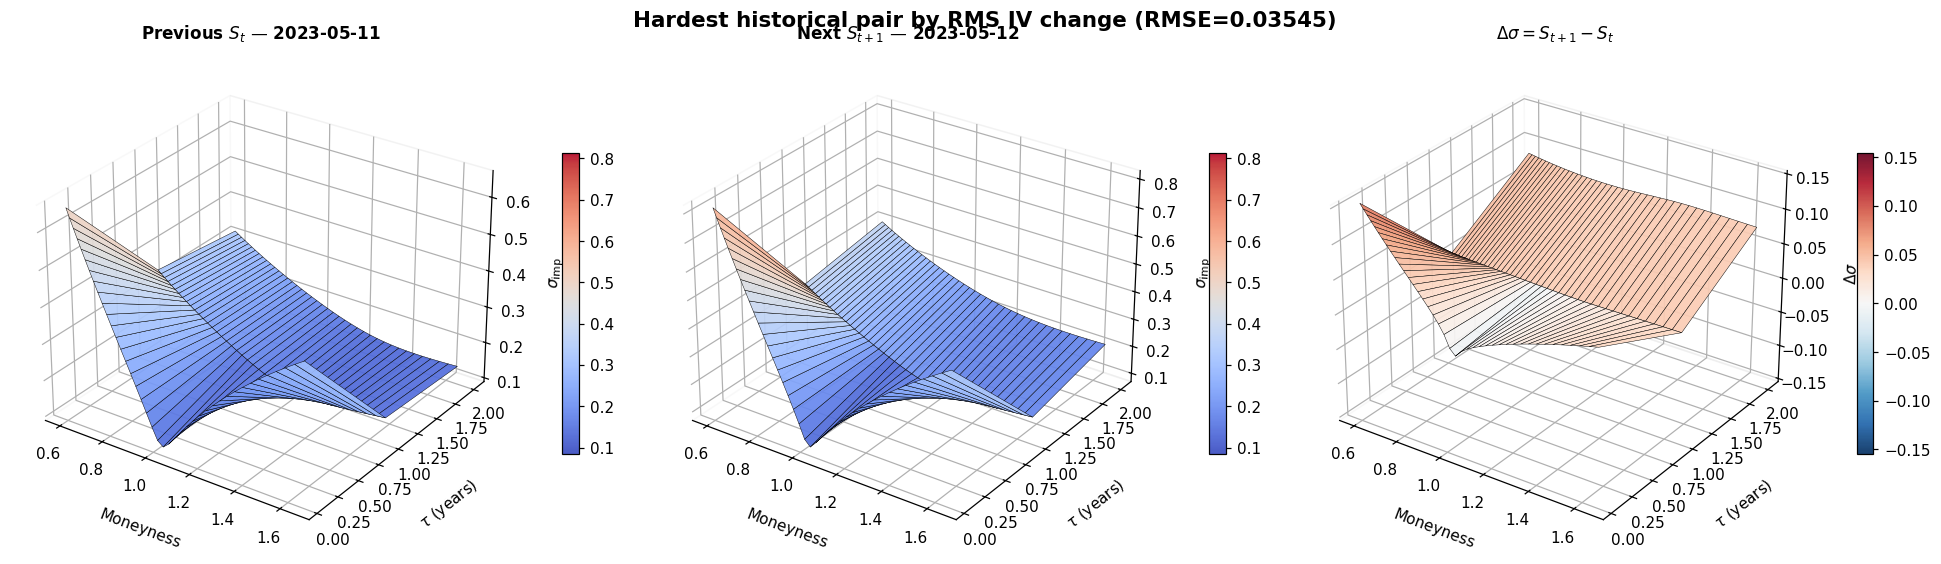

In [4]:
# Pairs are stored as raw implied vol on the unified grid (same units as training targets).
# Rank historical pairs by RMS day-over-day IV change; `HARD_*` is reused below for model comparison.
HARD_HIST_AVAILABLE = False
HARD_HIST_J = None
HARD_S_CURR = None
HARD_S_NEXT = None
HARD_HIST_DATE_CURR = None
HARD_HIST_DATE_NEXT = None
HARD_HIST_JUMP_RMSE = None
HARD_HIST_MAX_ABS_DELTA = None

hist_mask = val_sources == 0
if not hist_mask.any():
    print("No historical validation pairs; nothing to rank.")
else:
    curr_h = val_pair_curr[hist_mask].astype(np.float64)
    next_h = val_pair_next[hist_mask].astype(np.float64)
    delta_h = next_h - curr_h
    rmse = np.sqrt(np.nanmean(delta_h**2, axis=(1, 2)))
    j = int(np.argmax(rmse))
    s_curr = curr_h[j]
    s_next = next_h[j]
    d0 = val_hist_curr_dates[j]
    d1 = val_hist_next_dates[j]

    HARD_HIST_AVAILABLE = True
    HARD_HIST_J = j
    HARD_S_CURR = np.asarray(s_curr, dtype=np.float64)
    HARD_S_NEXT = np.asarray(s_next, dtype=np.float64)
    HARD_HIST_DATE_CURR = d0
    HARD_HIST_DATE_NEXT = d1
    HARD_HIST_JUMP_RMSE = float(rmse[j])
    HARD_HIST_MAX_ABS_DELTA = float(np.nanmax(np.abs(delta_h[j])))

    print(
        f"Largest historical IV jump: within-hist index j={j}  "
        f"RMSE(S_{{t+1}} - S_t)={HARD_HIST_JUMP_RMSE:.6f}  "
        f"max|Δσ|={HARD_HIST_MAX_ABS_DELTA:.6f}"
    )
    print(f"  previous quote date: {d0.date()}  →  next quote date: {d1.date()}")

    m_axis = np.asarray(moneyness, dtype=np.float64)
    tau_axis = np.asarray(GRID.tau, dtype=np.float64)
    MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")
    _SURF_CMAP = "coolwarm"
    _DIFF_CMAP = "RdBu_r"
    delta = s_next - s_curr
    shared_iv = np.concatenate([s_curr[:, tenor_idx].ravel(), s_next[:, tenor_idx].ravel()])
    shared_vmin = float(np.nanmin(shared_iv))
    shared_vmax = float(np.nanmax(shared_iv))
    if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
        shared_vmin, shared_vmax = 0.0, 1.0

    panels = [
        (s_curr, f"Previous $S_t$ — {d0.date()}", _SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False, shared_vmin, shared_vmax),
        (s_next, f"Next $S_{{t+1}}$ — {d1.date()}", _SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False, shared_vmin, shared_vmax),
        (delta, r"$\Delta\sigma = S_{t+1} - S_t$", _DIFF_CMAP, r"$\Delta\sigma$", True, None, None),
    ]

    fig = plt.figure(figsize=(18.0, 5.2))
    fig.suptitle(
        f"Hardest historical pair by RMS IV change (RMSE={rmse[j]:.5f})",
        fontsize=14,
        fontweight="bold",
    )
    for col, (iv, title, cmap, zlabel, is_diff, vmin_i, vmax_i) in enumerate(panels):
        ax = fig.add_subplot(1, 3, col + 1, projection="3d")
        iv_5 = iv[:, tenor_idx]
        if is_diff:
            panel_abs = float(np.nanmax(np.abs(iv_5)))
            if not np.isfinite(panel_abs) or panel_abs == 0.0:
                panel_abs = 1e-6
            vmin_, vmax_ = -panel_abs, panel_abs
            ax.set_zlim(vmin_, vmax_)
        else:
            vmin_, vmax_ = vmin_i, vmax_i
        surf = ax.plot_surface(
            MM_5,
            TT_5,
            iv_5,
            cmap=cmap,
            vmin=vmin_,
            vmax=vmax_,
            linewidth=0.3,
            edgecolor="k",
            alpha=0.92,
            antialiased=True,
            rstride=1,
            cstride=1,
        )
        ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
        ax.set_xlabel("Moneyness", labelpad=8)
        ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
        ax.set_zlabel(zlabel, labelpad=6)
        ax.view_init(elev=28, azim=-55)
        ax.tick_params(pad=2)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.08, aspect=18)
    fig.tight_layout()
    plt.show()


## Conditional forecast

In [5]:
def _surface_label(src_id, pair_idx):
    if src_id == 0:
        if pair_idx < len(val_hist_curr_dates):
            return (
                f"date={val_hist_curr_dates[pair_idx].date()}",
                f"date={val_hist_next_dates[pair_idx].date()}",
            )
        return f"idx={pair_idx}", f"idx={pair_idx}"
    if src_id == 1:
        path = int(val_heston_paths[pair_idx])
        step = int(val_heston_steps[pair_idx])
        return f"path={path}, step={step}", f"path={path}, step={step + 1}"
    path = int(val_sabr_paths[pair_idx])
    step = int(val_sabr_steps[pair_idx])
    return f"path={path}, step={step}", f"path={path}, step={step + 1}"


def _maybe_guard(iv):
    if not APPLY_CALENDAR_REPAIR:
        return np.asarray(iv, dtype=np.float64)
    iv_floor = np.clip(iv, IV_FLOOR_SAMPLE, None)
    return repair_calendar_monotone(iv_floor, GRID.tau)


def _arb_score(report):
    return float(
        max(
            -min(0.0, report.worst_butterfly),
            -min(0.0, report.worst_calendar),
            -min(0.0, report.worst_bound),
        )
    )


def _pick_validation_pair(src_id):
    rng = np.random.default_rng(VALIDATION_SEED + 5000 + src_id)
    n_pairs = pair_curr_by_src[src_id].shape[0]
    if n_pairs == 0:
        raise RuntimeError(f"No validation pairs available for source {src_id}")
    pick = int(rng.choice(n_pairs))
    s_curr = pair_curr_by_src[src_id][pick].astype(np.float64)
    s_next = pair_next_by_src[src_id][pick].astype(np.float64)
    input_label, gt_label = _surface_label(src_id, pick)
    return pick, s_curr, s_next, input_label, gt_label


@torch.no_grad()
def _conditional_forecast(s_curr, base_seed):
    cond_iv = torch.as_tensor(s_curr, dtype=torch.float32, device=DEVICE)[None, None]
    cond_z = model.normalize(cond_iv)

    best_forecast = None
    best_meta = None
    best_score = float("inf")

    for attempt in range(1, MAX_GENERATION_TRIES + 1):
        seed = int(base_seed + attempt - 1)
        if SAMPLER_USE_GENERATOR:
            sample_generator = torch.Generator().manual_seed(seed)
        else:
            sample_generator = None
            torch.manual_seed(seed)

        forecast_iv = (
            sampler.ddim_sample(
                batch_size=1,
                num_steps=DDIM_STEPS,
                eta=0.0,
                cond=cond_z,
                generator=sample_generator,
                clip_z=SAMPLER_CLIP_Z,
            )
            .detach()
            .cpu()
            .numpy()[0, 0]
            .astype(np.float64)
        )
        guarded = _maybe_guard(forecast_iv)
        report = check_iv_surface_arbitrage(
            guarded,
            moneyness,
            GRID.tau,
            spot=SPOT_REF,
            rate=RATE_REF,
            tol=GENERATED_ARB_TOL,
        )
        score = _arb_score(report)
        if score < best_score:
            best_score = score
            best_forecast = guarded
            best_meta = {
                "base_seed": int(base_seed),
                "accepted_seed": seed,
                "attempts": attempt,
                "forecast_arb_free": bool(report.arbitrage_free),
                "forecast_arb_tol": GENERATED_ARB_TOL,
                "worst_butterfly": float(report.worst_butterfly),
                "worst_calendar": float(report.worst_calendar),
                "worst_bound": float(report.worst_bound),
            }
        if report.arbitrage_free:
            break

    assert best_forecast is not None and best_meta is not None
    return best_forecast, best_meta


instances = []
for instance_idx, path_type in enumerate(PATH_TYPES):
    src_id = PATH_TYPE_TO_SRC_ID[path_type]
    pick, s_curr, s_next, input_label, gt_label = _pick_validation_pair(src_id)
    base_seed = int(GENERATION_SEEDS[instance_idx])
    forecast, meta = _conditional_forecast(s_curr, base_seed)
    instances.append(
        {
            "path_type": path_type,
            "pair_idx": pick,
            "input_label": input_label,
            "gt_label": gt_label,
            "input": s_curr,
            "ground_truth": s_next,
            "forecast": forecast,
            "meta": meta,
        }
    )

surface_inputs_df = pd.DataFrame(
    [
        {
            "instance": i + 1,
            "path_type": inst["path_type"],
            "pair_idx": int(inst["pair_idx"]),
            "input_label": inst["input_label"],
            "gt_label": inst["gt_label"],
            "base_seed": int(inst["meta"]["base_seed"]),
            "accepted_seed": int(inst["meta"]["accepted_seed"]),
            "generation_attempts": int(inst["meta"]["attempts"]),
            "forecast_arb_free": bool(inst["meta"]["forecast_arb_free"]),
            "worst_butterfly": float(inst["meta"]["worst_butterfly"]),
            "worst_calendar": float(inst["meta"]["worst_calendar"]),
            "worst_bound": float(inst["meta"]["worst_bound"]),
            "tenor_years_shown": np.round(GRID.tau[tenor_idx], 4).tolist(),
        }
        for i, inst in enumerate(instances)
    ]
)
display(surface_inputs_df)

,instance,path_type,pair_idx,input_label,gt_label,base_seed,accepted_seed,generation_attempts,forecast_arb_free,worst_butterfly,worst_calendar,worst_bound,tenor_years_shown
0,1,historical,76,date=2023-04-24,date=2023-04-25,9042,9052,11,False,-0.299930,-5.551115e-17,2.178935e-06,"[0.05, 1.05, 2.0]"
1,2,sabr,29,"path=13, step=29","path=13, step=30",9043,9043,1,True,-0.000056,-1.734723e-18,-2.131628e-14,"[0.05, 1.05, 2.0]"
2,3,heston,57,"path=12, step=57","path=12, step=58",9044,9052,9,False,-0.438351,-8.326673e-17,1.061537e-05,"[0.05, 1.05, 2.0]"


## Model forecast on the largest historical IV jump

**Run this cell after the “Conditional forecast” cell** (it needs `_conditional_forecast`). It samples the same historical transition identified above ($S_t$ on the first quote date → $S_{t+1}$ on the next): **3D slices** on the configured tenors, then **full moneyness–τ heatmaps** for GT, model forecast, and forecast − GT.


Forecast vs GT (next surface): RMSE=0.024627  MAE=0.020250  arb_free=False  attempts=16  seed=7757
  Realized jump (GT − prev) RMS=0.035449 — forecast error measures how well the model predicts that move from $S_t$.


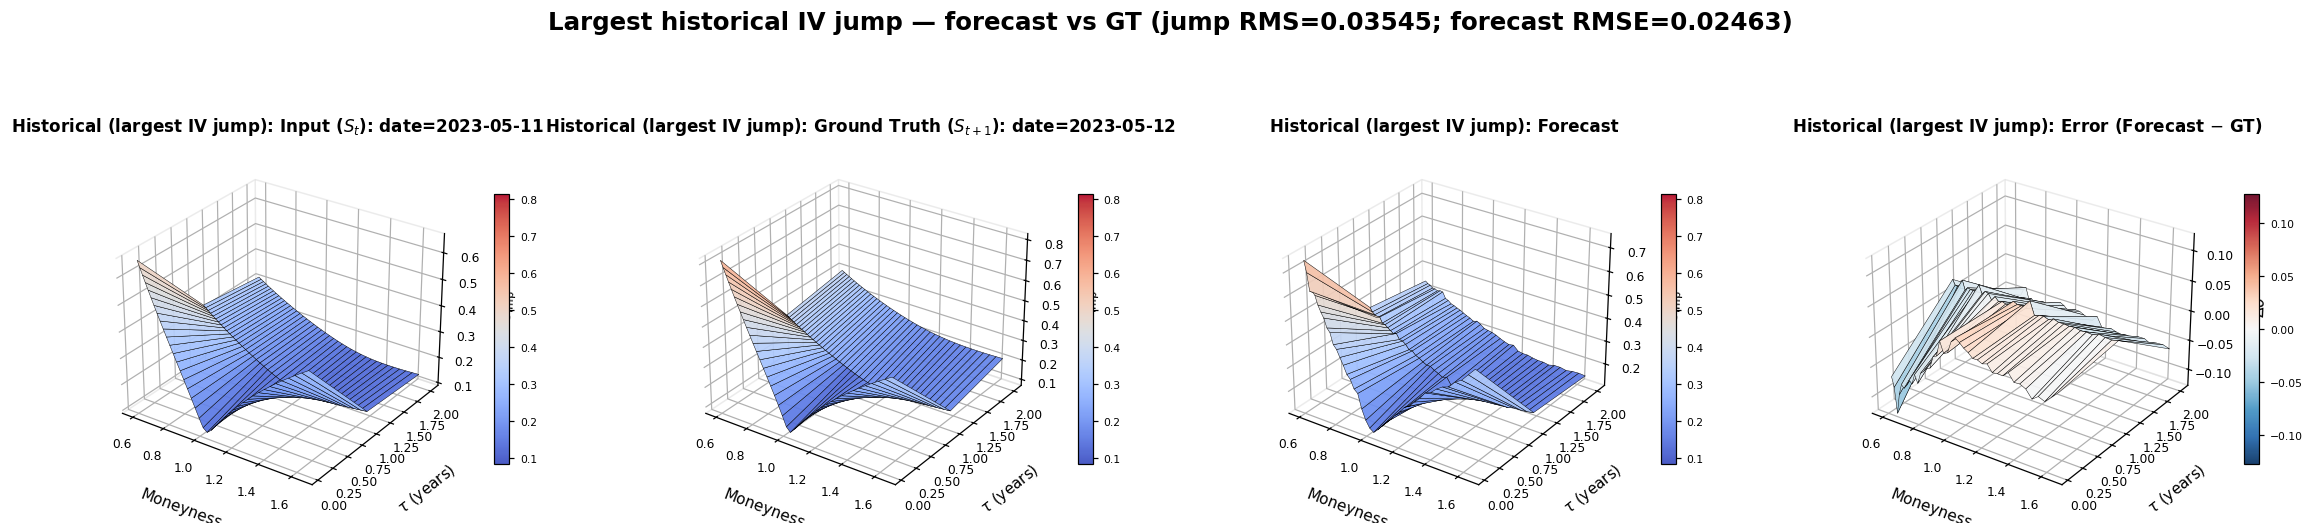

In [6]:
if not HARD_HIST_AVAILABLE:
    print("Skipping model comparison: no historical validation pairs.")
else:
    HARD_JUMP_FORECAST_SEED = int(VALIDATION_SEED + 7700)
    hard_forecast, hard_meta = _conditional_forecast(HARD_S_CURR, HARD_JUMP_FORECAST_SEED)
    hard_err = hard_forecast - HARD_S_NEXT
    hard_rmse = float(np.sqrt(np.nanmean(hard_err**2)))
    hard_mae = float(np.nanmean(np.abs(hard_err)))
    print(
        f"Forecast vs GT (next surface): RMSE={hard_rmse:.6f}  MAE={hard_mae:.6f}  "
        f"arb_free={hard_meta['forecast_arb_free']}  attempts={hard_meta['attempts']}  "
        f"seed={hard_meta['accepted_seed']}"
    )
    print(
        f"  Realized jump (GT − prev) RMS={HARD_HIST_JUMP_RMSE:.6f} — "
        "forecast error measures how well the model predicts that move from $S_t$."
    )

    m_axis = np.asarray(moneyness, dtype=np.float64)
    tau_axis = np.asarray(GRID.tau, dtype=np.float64)
    MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")

    _SURF_CMAP = "coolwarm"
    _DIFF_CMAP = "RdBu_r"
    _3D_STYLE = {
        "font.family": "sans-serif",
        "axes.labelsize": 10,
        "axes.titlesize": 12,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }

    inst = {
        "input": HARD_S_CURR,
        "ground_truth": HARD_S_NEXT,
        "forecast": hard_forecast,
        "input_label": f"date={HARD_HIST_DATE_CURR.date()}",
        "gt_label": f"date={HARD_HIST_DATE_NEXT.date()}",
    }

    with plt.rc_context(_3D_STYLE):
        fig3d = plt.figure(figsize=(26.0, 5.8))
        fig3d.subplots_adjust(wspace=0.25, hspace=0.35)

        path_label = "Historical (largest IV jump)"
        panels = [
            (
                inst["input"],
                f"Input ($S_t$): {inst['input_label']}",
                _SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (
                inst["ground_truth"],
                f"Ground Truth ($S_{{t+1}}$): {inst['gt_label']}",
                _SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (inst["forecast"], "Forecast", _SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
            (
                inst["forecast"] - inst["ground_truth"],
                "Error (Forecast $-$ GT)",
                _DIFF_CMAP,
                r"$\Delta\sigma$",
                True,
            ),
        ]

        all_iv_vals = np.concatenate(
            [
                inst["input"][:, tenor_idx].ravel(),
                inst["ground_truth"][:, tenor_idx].ravel(),
                inst["forecast"][:, tenor_idx].ravel(),
            ]
        )
        shared_vmin = float(np.nanmin(all_iv_vals))
        shared_vmax = float(np.nanmax(all_iv_vals))
        if (
            (not np.isfinite(shared_vmin))
            or (not np.isfinite(shared_vmax))
            or shared_vmin == shared_vmax
        ):
            shared_vmin, shared_vmax = 0.0, 1.0

        for col, (iv, title, cmap, zlabel, is_diff) in enumerate(panels):
            ax = fig3d.add_subplot(1, 4, col + 1, projection="3d")
            iv_5 = iv[:, tenor_idx]
            if is_diff:
                panel_abs = float(np.nanmax(np.abs(iv_5)))
                if not np.isfinite(panel_abs) or panel_abs == 0.0:
                    panel_abs = 1.0
                vmin_, vmax_ = -panel_abs, panel_abs
                ax.set_zlim(vmin_, vmax_)
            else:
                vmin_, vmax_ = shared_vmin, shared_vmax

            plotted = ax.plot_surface(
                MM_5,
                TT_5,
                iv_5,
                cmap=cmap,
                vmin=vmin_,
                vmax=vmax_,
                linewidth=0.3,
                edgecolor="k",
                alpha=0.92,
                antialiased=True,
                rstride=1,
                cstride=1,
            )
            ax.set_title(f"{path_label}: {title}", fontsize=11, fontweight="bold", pad=12)
            ax.set_xlabel("Moneyness", labelpad=8)
            ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
            ax.set_zlabel(zlabel, labelpad=6)
            ax.view_init(elev=28, azim=-55)
            ax.tick_params(pad=2)
            ax.xaxis.pane.fill = False
            ax.yaxis.pane.fill = False
            ax.zaxis.pane.fill = False
            ax.xaxis.pane.set_edgecolor("0.85")
            ax.yaxis.pane.set_edgecolor("0.85")
            ax.zaxis.pane.set_edgecolor("0.85")
            cbar = fig3d.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)
            cbar.ax.tick_params(labelsize=7)

        fig3d.suptitle(
            f"Largest historical IV jump — forecast vs GT (jump RMS={HARD_HIST_JUMP_RMSE:.5f}; "
            f"forecast RMSE={hard_rmse:.5f})",
            fontsize=16,
            fontweight="bold",
            y=0.995,
        )
        plt.show()


## No-arbitrage diagnostics

In [7]:
def _report_row(kind, instance, path_type, label, iv):
    strict = check_iv_surface_arbitrage(iv, moneyness, GRID.tau, spot=SPOT_REF, rate=RATE_REF, tol=ARB_DIAG_TOL)
    soft = check_iv_surface_arbitrage(iv, moneyness, GRID.tau, spot=SPOT_REF, rate=RATE_REF, tol=ARB_ACCEPT_TOL)
    return {
        "instance": instance,
        "path_type": path_type,
        "kind": kind,
        "label": label,
        "strict_arb_free": bool(strict.arbitrage_free),
        "soft_arb_free": bool(soft.arbitrage_free),
        "worst_butterfly": float(strict.worst_butterfly),
        "worst_calendar": float(strict.worst_calendar),
        "worst_bound": float(strict.worst_bound),
        "n_butterfly": int(strict.n_butterfly_violations),
        "n_calendar": int(strict.n_calendar_violations),
        "n_bound": int(strict.n_bound_violations),
    }


validation_rows = []
for i, inst in enumerate(instances, start=1):
    path_type = str(inst["path_type"])
    validation_rows.append(
        _report_row(f"input ($S_t$): {inst['input_label']}", i, path_type, inst["input_label"], inst["input"])
    )
    validation_rows.append(
        _report_row(
            f"ground truth ($S_{{t+1}}$): {inst['gt_label']}", i, path_type, inst["gt_label"], inst["ground_truth"]
        )
    )
    validation_rows.append(
        _report_row(
            "forecast",
            i,
            path_type,
            f"forecast (seed={inst['meta']['accepted_seed']})",
            inst["forecast"],
        )
    )

surface_validation_df = pd.DataFrame(validation_rows)
display(surface_validation_df)

forecast_error_rows = []
for i, inst in enumerate(instances, start=1):
    diff = inst["forecast"] - inst["ground_truth"]
    diff_5 = diff[:, tenor_idx]
    gt = inst["ground_truth"]
    gt_abs = np.abs(np.asarray(gt, dtype=float))
    mape_mask = np.isfinite(diff) & np.isfinite(gt) & (gt_abs > float(IV_FLOOR_SAMPLE))
    mape_pct = (
        float(100.0 * np.mean(np.abs(diff[mape_mask]) / gt_abs[mape_mask]))
        if np.any(mape_mask)
        else float("nan")
    )
    forecast_error_rows.append(
        {
            "instance": i,
            "path_type": inst["path_type"],
            "input_label": inst["input_label"],
            "gt_label": inst["gt_label"],
            "forecast_seed": int(inst["meta"]["accepted_seed"]),
            "mean_error": float(np.nanmean(diff)),
            "mae": float(np.nanmean(np.abs(diff))),
            "rmse": float(np.sqrt(np.nanmean(diff * diff))),
            "mape_pct": mape_pct,
            "max_abs_error": float(np.nanmax(np.abs(diff))),
            "rmse_on_5_plotted_tenors": float(np.sqrt(np.nanmean(diff_5 * diff_5))),
        }
    )

forecast_error_df = pd.DataFrame(forecast_error_rows)
display(forecast_error_df)

,instance,path_type,kind,label,strict_arb_free,soft_arb_free,worst_butterfly,worst_calendar,worst_bound,n_butterfly,n_calendar,n_bound
0,1,historical,input ($S_t$): date=2023-04-24,date=2023-04-24,False,False,1.971926e-09,-1.774260e-03,1.095854e-07,0,65,0
1,1,historical,ground truth ($S_{t+1}$): date=2023-04-25,date=2023-04-25,False,False,2.146627e-09,-2.525801e-03,1.052914e-07,0,71,0
2,1,historical,forecast,forecast (seed=9052),False,False,-2.999301e-01,-5.551115e-17,2.178935e-06,525,0,0
3,2,sabr,"input ($S_t$): path=13, step=29","path=13, step=29",True,True,-3.780959e-15,6.412526e-05,-2.131628e-14,0,0,0
4,2,sabr,"ground truth ($S_{t+1}$): path=13, step=30","path=13, step=30",True,True,-3.780959e-15,6.591948e-05,-2.131628e-14,0,0,0
5,2,sabr,forecast,forecast (seed=9043),False,True,-5.575395e-05,-1.734723e-18,-2.131628e-14,8,0,0
6,3,heston,"input ($S_t$): path=12, step=57","path=12, step=57",True,True,3.177062e-07,4.334185e-03,4.849070e-07,0,0,0
7,3,heston,"ground truth ($S_{t+1}$): path=12, step=58","path=12, step=58",True,True,6.068432e-07,4.349332e-03,1.124582e-06,0,0,0
8,3,heston,forecast,forecast (seed=9052),False,False,-4.383511e-01,-8.326673e-17,1.061537e-05,634,0,0


,instance,path_type,input_label,gt_label,forecast_seed,mean_error,mae,rmse,mape_pct,max_abs_error,rmse_on_5_plotted_tenors
0,1,historical,date=2023-04-24,date=2023-04-25,9052,0.020237,0.020276,0.022332,9.488184,0.066090,0.022648
1,2,sabr,"path=13, step=29","path=13, step=30",9043,-0.000232,0.000802,0.000973,1.743667,0.003486,0.000950
2,3,heston,"path=12, step=57","path=12, step=58",9052,0.014876,0.015388,0.017402,4.418109,0.045804,0.019401


## IV distribution: ground truth vs forecast (historical only)

Summary statistics are computed over **all** moneyness–tenor grid points (finite values only): mean, standard deviation, min / max, and quartiles. Tables and the histogram compare **historical path** ground truth $S_{t+1}$ to the model **forecast** for the same evaluated instance(s) picked in this notebook.

In [8]:
def _finite_iv_stats(iv: np.ndarray) -> dict:
    v = np.asarray(iv, dtype=np.float64).ravel()
    v = v[np.isfinite(v)]
    if v.size == 0:
        nan = float("nan")
        return {
            "n": 0,
            "mean": nan,
            "std": nan,
            "min": nan,
            "p25": nan,
            "p50": nan,
            "p75": nan,
            "max": nan,
        }
    return {
        "n": int(v.size),
        "mean": float(np.mean(v)),
        "std": float(np.std(v, ddof=1)) if v.size > 1 else 0.0,
        "min": float(np.min(v)),
        "p25": float(np.percentile(v, 25)),
        "p50": float(np.percentile(v, 50)),
        "p75": float(np.percentile(v, 75)),
        "max": float(np.max(v)),
    }


def _stats_side_by_side(gt: np.ndarray, pred=None) -> dict:
    g = _finite_iv_stats(gt)
    if pred is None:
        p = {k: float("nan") for k in g}
    else:
        p = _finite_iv_stats(pred)
    return {
        "n_gt": g["n"],
        "n_pred": p["n"],
        "mean_gt": g["mean"],
        "mean_pred": p["mean"],
        "std_gt": g["std"],
        "std_pred": p["std"],
        "min_gt": g["min"],
        "min_pred": p["min"],
        "p25_gt": g["p25"],
        "p25_pred": p["p25"],
        "p50_gt": g["p50"],
        "p50_pred": p["p50"],
        "p75_gt": g["p75"],
        "p75_pred": p["p75"],
        "max_gt": g["max"],
        "max_pred": p["max"],
    }


_cols_order = [
    "instance",
    "path_type",
    "n_gt",
    "n_pred",
    "mean_gt",
    "mean_pred",
    "std_gt",
    "std_pred",
    "min_gt",
    "min_pred",
    "p25_gt",
    "p25_pred",
    "p50_gt",
    "p50_pred",
    "p75_gt",
    "p75_pred",
    "max_gt",
    "max_pred",
]

# Use iv_hist_* names so this cell does not define _hist_* variables used by model performance metrics below.
iv_hist_instances = [inst for inst in instances if inst["path_type"] == "historical"]
_per_instance_rows = []
for inst in iv_hist_instances:
    i = int(instances.index(inst)) + 1
    row = {"instance": i, "path_type": inst["path_type"]}
    row.update(_stats_side_by_side(inst["ground_truth"], inst["forecast"]))
    _per_instance_rows.append(row)

if _per_instance_rows:
    iv_stats_by_instance_df = pd.DataFrame(_per_instance_rows)[_cols_order]
    display(iv_stats_by_instance_df)
else:
    iv_stats_by_instance_df = pd.DataFrame(columns=_cols_order)
    print("No historical instance in `instances`; skipping per-instance IV stats table.")

if iv_hist_instances:
    iv_hist_gt_eval = np.concatenate([inst["ground_truth"].ravel() for inst in iv_hist_instances])
    iv_hist_fc_eval = np.concatenate([inst["forecast"].ravel() for inst in iv_hist_instances])
else:
    iv_hist_gt_eval = np.array([], dtype=np.float64)
    iv_hist_fc_eval = np.array([], dtype=np.float64)

iv_stats_summary_df = pd.DataFrame(
    [
        {
            "scope": "historical path — evaluated instance(s): GT vs forecast",
            **_stats_side_by_side(iv_hist_gt_eval, iv_hist_fc_eval),
        },
    ]
)
display(iv_stats_summary_df)

,instance,path_type,n_gt,n_pred,mean_gt,mean_pred,std_gt,std_pred,min_gt,min_pred,p25_gt,p25_pred,p50_gt,p50_pred,p75_gt,p75_pred,max_gt,max_pred
0,1,historical,1640,1640,0.219272,0.239509,0.082823,0.088605,0.118229,0.12596,0.143808,0.158221,0.200216,0.21887,0.277032,0.304571,0.653004,0.712579


,scope,n_gt,n_pred,mean_gt,mean_pred,std_gt,std_pred,min_gt,min_pred,p25_gt,p25_pred,p50_gt,p50_pred,p75_gt,p75_pred,max_gt,max_pred
0,historical path — evaluated instance(s): GT vs...,1640,1640,0.219272,0.239509,0.082823,0.088605,0.118229,0.12596,0.143808,0.158221,0.200216,0.21887,0.277032,0.304571,0.653004,0.712579


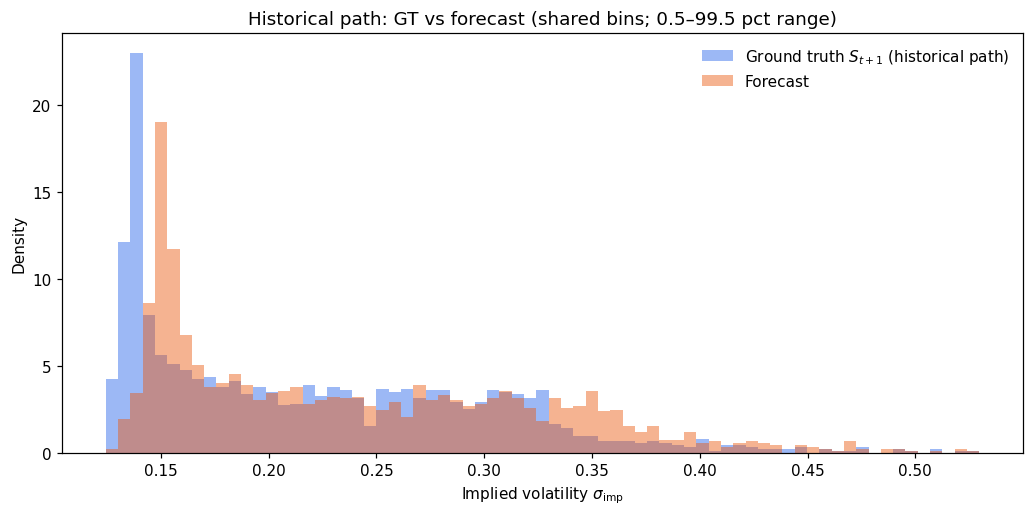

In [9]:
# Historical path: ground truth $S_{t+1}$ vs model forecast (same evaluated instance(s) as the notebook pick).
# Semi-transparent overlapping histograms; shared bins from 0.5–99.5 pct of GT ∪ forecast samples.
_iv_dist_gt_eval = np.asarray(iv_hist_gt_eval, dtype=np.float64).ravel()
_iv_dist_gt_eval = _iv_dist_gt_eval[np.isfinite(_iv_dist_gt_eval)]
_iv_dist_fc_eval = np.asarray(iv_hist_fc_eval, dtype=np.float64).ravel()
_iv_dist_fc_eval = _iv_dist_fc_eval[np.isfinite(_iv_dist_fc_eval)]

if _iv_dist_gt_eval.size and _iv_dist_fc_eval.size:
    _iv_dist_combined = np.concatenate([_iv_dist_gt_eval, _iv_dist_fc_eval])
    _iv_dist_lo, _iv_dist_hi = np.percentile(_iv_dist_combined, [0.5, 99.5])
    if not np.isfinite(_iv_dist_lo) or not np.isfinite(_iv_dist_hi) or _iv_dist_lo >= _iv_dist_hi:
        _iv_dist_lo, _iv_dist_hi = float(np.min(_iv_dist_combined)), float(np.max(_iv_dist_combined))
    if _iv_dist_lo >= _iv_dist_hi:
        _iv_dist_hi = _iv_dist_lo + 1e-6
    _iv_dist_bins = np.linspace(_iv_dist_lo, _iv_dist_hi, 72)

    _fig_iv_dist, _ax_iv_dist = plt.subplots(figsize=(9.5, 4.8))
    _ax_iv_dist.hist(
        _iv_dist_gt_eval,
        bins=_iv_dist_bins,
        density=True,
        alpha=0.45,
        color="#2563eb",
        label="Ground truth $S_{t+1}$ (historical path)",
        histtype="stepfilled",
        edgecolor="none",
    )
    _ax_iv_dist.hist(
        _iv_dist_fc_eval,
        bins=_iv_dist_bins,
        density=True,
        alpha=0.45,
        color="#ea580c",
        label="Forecast",
        histtype="stepfilled",
        edgecolor="none",
    )
    _ax_iv_dist.set_xlabel(r"Implied volatility $\sigma_{\mathrm{imp}}$")
    _ax_iv_dist.set_ylabel("Density")
    _ax_iv_dist.set_title("Historical path: GT vs forecast (shared bins; 0.5–99.5 pct range)")
    _ax_iv_dist.legend(loc="upper right", frameon=False)
    _fig_iv_dist.tight_layout()
    plt.show()
else:
    print("Skipping IV histogram: run the IV statistics cell first, or missing historical GT/forecast samples.")

## Model forecast

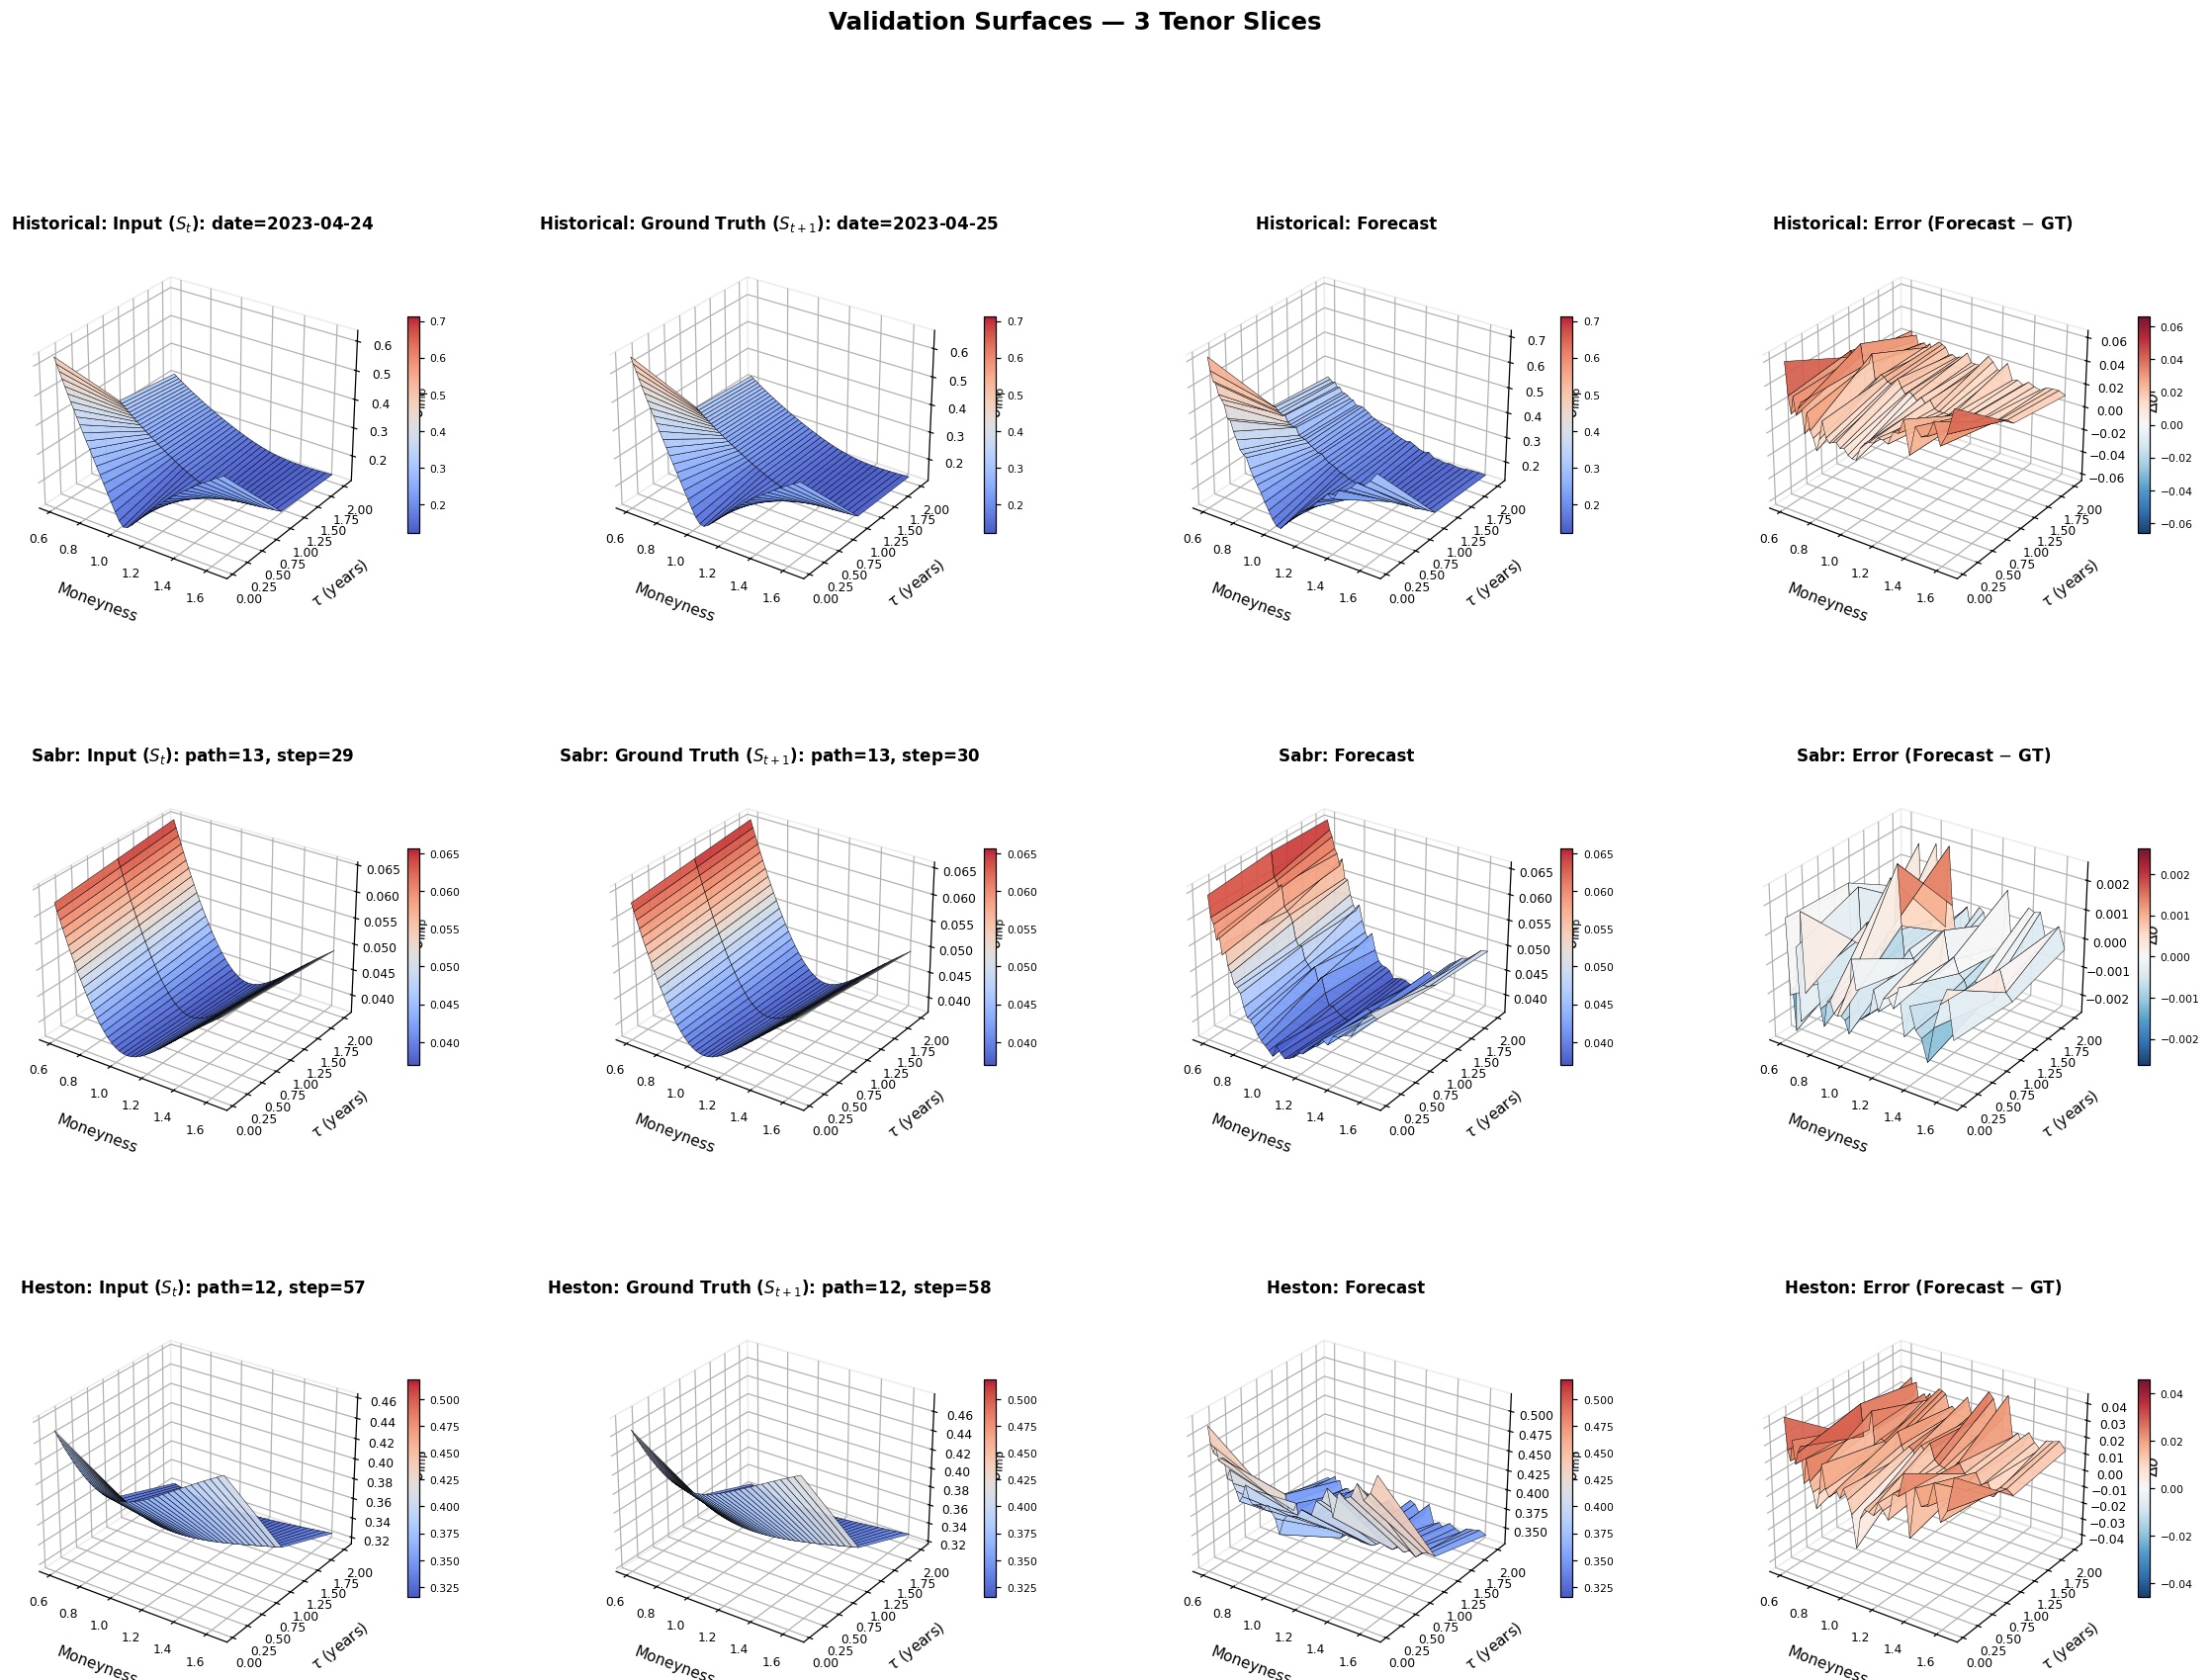

In [ ]:
m_axis = np.asarray(moneyness, dtype=np.float64)
tau_axis = np.asarray(GRID.tau, dtype=np.float64)
MM_5, TT_5 = np.meshgrid(m_axis, tau_axis[tenor_idx], indexing="ij")

n_instances = len(instances)

_SURF_CMAP = "coolwarm"
_DIFF_CMAP = "RdBu_r"

_3D_STYLE = {
    "font.family": "sans-serif",
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

with plt.rc_context(_3D_STYLE):
    fig3d = plt.figure(figsize=(26.0, 5.8 * n_instances))
    fig3d.subplots_adjust(wspace=0.25, hspace=0.35)

    for row, inst in enumerate(instances):
        path_label = inst["path_type"].capitalize()
        panels = [
            (inst["input"], f"Input ($S_t$): {inst['input_label']}", _SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
            (
                inst["ground_truth"],
                f"Ground Truth ($S_{{t+1}}$): {inst['gt_label']}",
                _SURF_CMAP,
                r"$\sigma_{\mathrm{imp}}$",
                False,
            ),
            (inst["forecast"], "Forecast", _SURF_CMAP, r"$\sigma_{\mathrm{imp}}$", False),
            (inst["forecast"] - inst["ground_truth"], "Error (Forecast $-$ GT)", _DIFF_CMAP, r"$\Delta\sigma$", True),
        ]

        all_iv_vals = np.concatenate(
            [
                inst["input"][:, tenor_idx].ravel(),
                inst["ground_truth"][:, tenor_idx].ravel(),
                inst["forecast"][:, tenor_idx].ravel(),
            ]
        )
        shared_vmin = float(np.nanmin(all_iv_vals))
        shared_vmax = float(np.nanmax(all_iv_vals))
        if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
            shared_vmin, shared_vmax = 0.0, 1.0

        for col, (iv, title, cmap, zlabel, is_diff) in enumerate(panels):
            ax = fig3d.add_subplot(n_instances, 4, 4 * row + col + 1, projection="3d")
            iv_5 = iv[:, tenor_idx]
            if is_diff:
                panel_abs = float(np.nanmax(np.abs(iv_5)))
                if not np.isfinite(panel_abs) or panel_abs == 0.0:
                    panel_abs = 1.0
                vmin_, vmax_ = -panel_abs, panel_abs
                ax.set_zlim(vmin_, vmax_)
            else:
                vmin_, vmax_ = shared_vmin, shared_vmax

            plotted = ax.plot_surface(
                MM_5,
                TT_5,
                iv_5,
                cmap=cmap,
                vmin=vmin_,
                vmax=vmax_,
                linewidth=0.3,
                edgecolor="k",
                alpha=0.92,
                antialiased=True,
                rstride=1,
                cstride=1,
            )
            ax.set_title(f"{path_label}: {title}", fontsize=11, fontweight="bold", pad=12)
            ax.set_xlabel("Moneyness", labelpad=8)
            ax.set_ylabel(r"$\tau$ (years)", labelpad=10)
            ax.set_zlabel(zlabel, labelpad=6)
            ax.view_init(elev=28, azim=-55)
            ax.tick_params(pad=2)
            ax.xaxis.pane.fill = False
            ax.yaxis.pane.fill = False
            ax.zaxis.pane.fill = False
            ax.xaxis.pane.set_edgecolor("0.85")
            ax.yaxis.pane.set_edgecolor("0.85")
            ax.zaxis.pane.set_edgecolor("0.85")

            cbar = fig3d.colorbar(plotted, ax=ax, shrink=0.55, pad=0.08, aspect=18)
            cbar.ax.tick_params(labelsize=7)

    fig3d.suptitle(
        f"Validation Surfaces — {TENOR_SLICES_PER_SURFACE} Tenor Slices",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )
    fig3d.savefig(
        "validation_input_ground_truth_forecast_difference_3d.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()
fig

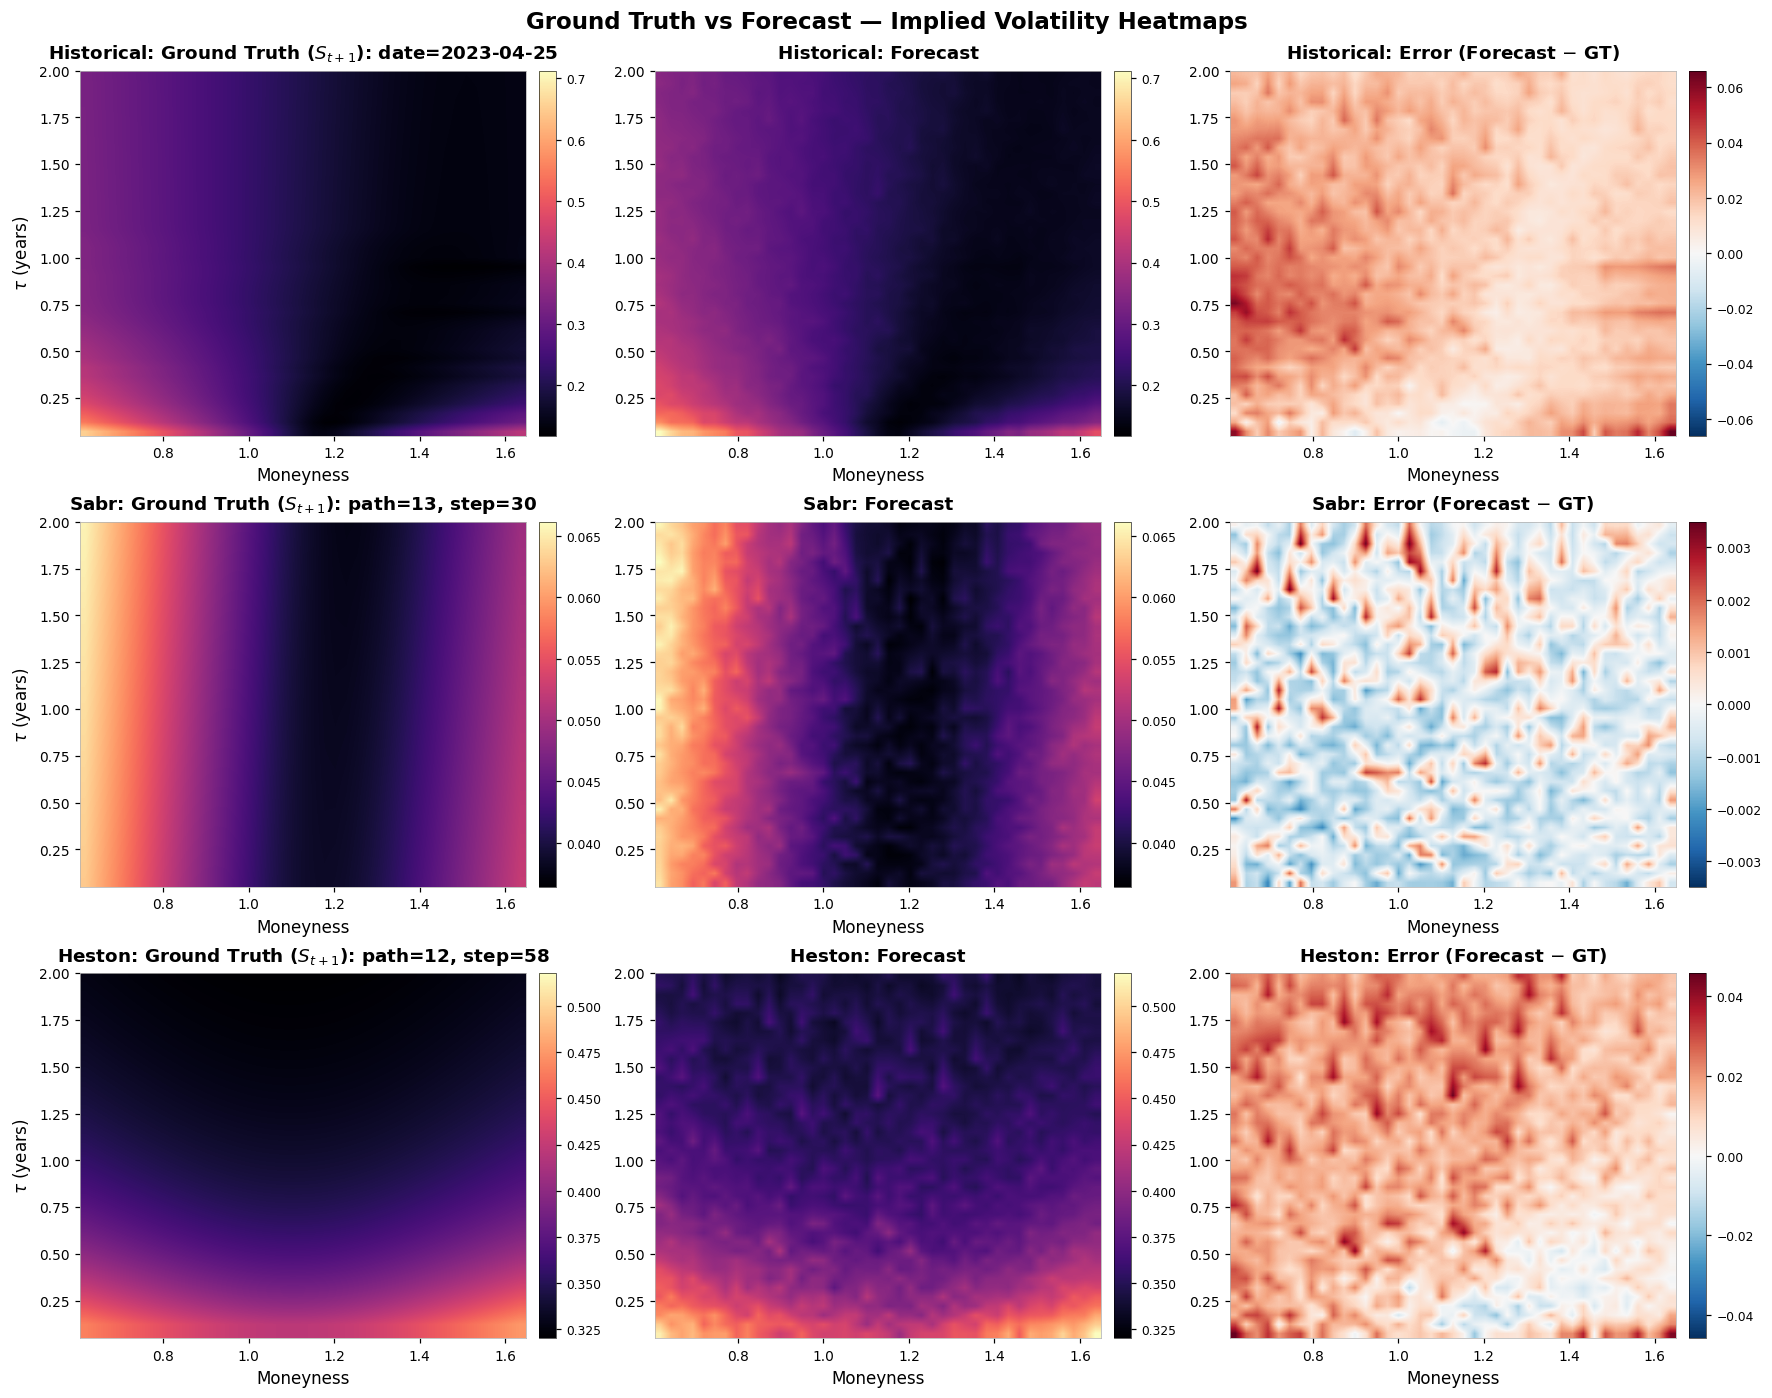

In [11]:
n_instances = len(instances)

_HM_STYLE = {
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
}

with plt.rc_context(_HM_STYLE):
    fig_hm, axes_hm = plt.subplots(
        n_instances,
        3,
        figsize=(16.0, 4.2 * n_instances),
        squeeze=False,
        constrained_layout=True,
    )

    for row, inst in enumerate(instances):
        gt = np.asarray(inst["ground_truth"], dtype=float)
        fc = np.asarray(inst["forecast"], dtype=float)
        err = fc - gt
        path_label = inst["path_type"].capitalize()

        shared_vmin = min(float(np.nanmin(gt)), float(np.nanmin(fc)))
        shared_vmax = max(float(np.nanmax(gt)), float(np.nanmax(fc)))
        if (not np.isfinite(shared_vmin)) or (not np.isfinite(shared_vmax)) or shared_vmin == shared_vmax:
            shared_vmin, shared_vmax = 0.0, 1.0

        panels = [
            (gt, f"Ground Truth ($S_{{t+1}}$): {inst['gt_label']}", "magma", r"$\sigma_{\mathrm{imp}}$", False),
            (fc, "Forecast", "magma", r"$\sigma_{\mathrm{imp}}$", False),
            (err, "Error (Forecast $-$ GT)", "RdBu_r", r"$\Delta\sigma$", True),
        ]

        for col, (mat, ttl, cmap, cbar_label, is_diff) in enumerate(panels):
            ax = axes_hm[row, col]
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("0.7")
                spine.set_linewidth(0.5)

            if is_diff:
                panel_abs = float(np.nanmax(np.abs(mat)))
                if not np.isfinite(panel_abs) or panel_abs == 0.0:
                    panel_abs = 1.0
                vmin_, vmax_ = -panel_abs, panel_abs
            else:
                vmin_, vmax_ = shared_vmin, shared_vmax

            image = ax.imshow(
                mat.T,
                origin="lower",
                aspect="auto",
                extent=(m_axis[0], m_axis[-1], tau_axis[0], tau_axis[-1]),
                cmap=cmap,
                vmin=vmin_,
                vmax=vmax_,
                interpolation="bilinear",
            )
            ax.set_title(f"{path_label}: {ttl}", fontweight="bold", pad=8)
            ax.set_xlabel("Moneyness")
            ax.set_ylabel(r"$\tau$ (years)" if col == 0 else "")
            ax.tick_params(direction="out")

            cbar = fig_hm.colorbar(image, ax=ax, fraction=0.046, pad=0.03, aspect=22)
            cbar.ax.tick_params(labelsize=8)
            cbar.outline.set_linewidth(0.4)

    fig_hm.suptitle(
        "Ground Truth vs Forecast — Implied Volatility Heatmaps",
        fontsize=15,
        fontweight="bold",
    )
    fig_hm.savefig(
        "validation_heatmap_ground_truth_vs_forecast.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()

## Cross-section at selected tenors

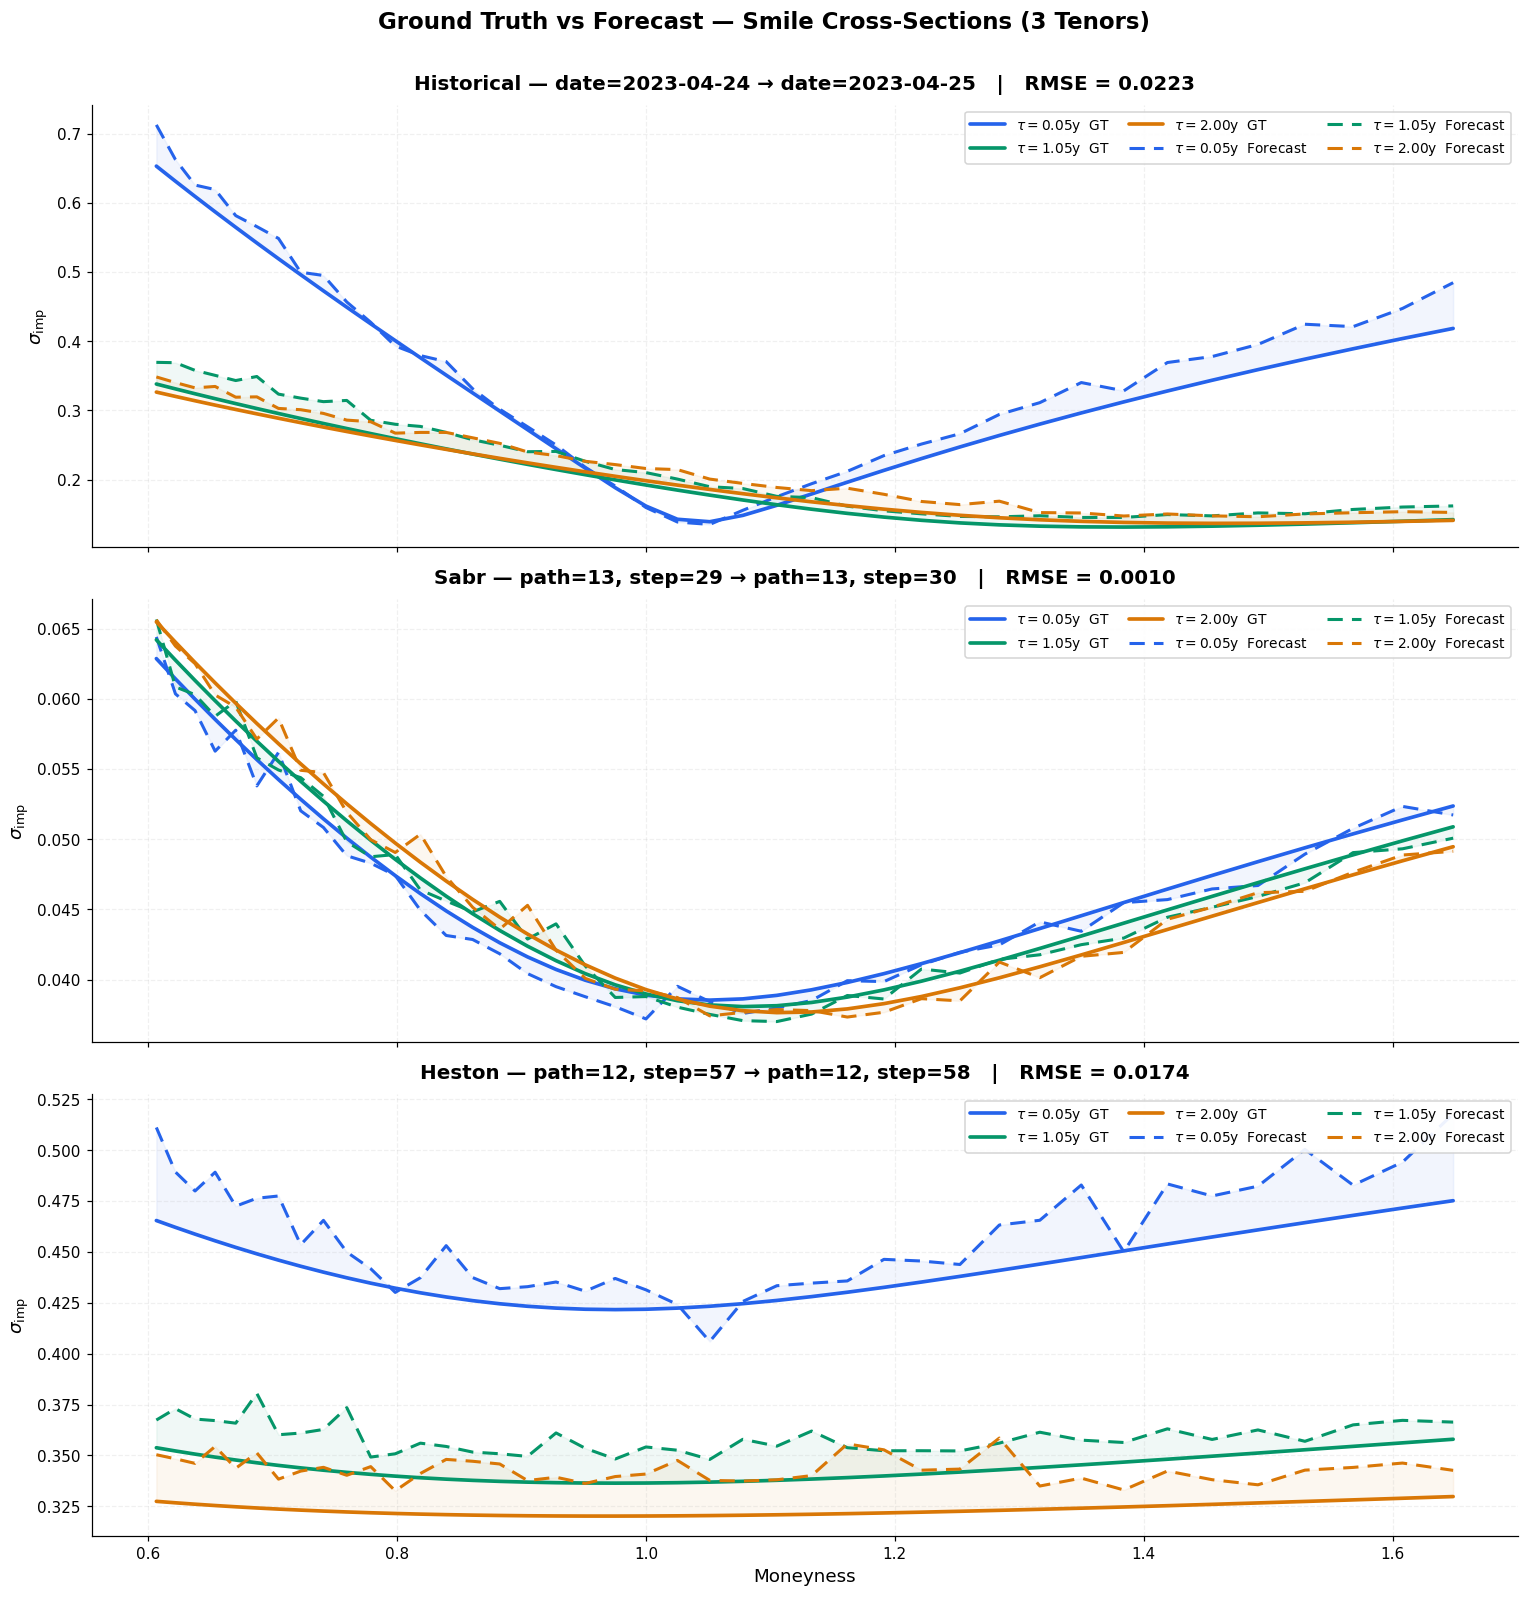

In [12]:
_TENOR_COLORS = ["#2563eb", "#059669", "#d97706", "#dc2626", "#7c3aed"]

_XS_STYLE = {
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "legend.framealpha": 0.92,
    "legend.edgecolor": "0.82",
}

with plt.rc_context(_XS_STYLE):
    fig, axes = plt.subplots(
        n_instances,
        1,
        figsize=(14, 4.8 * n_instances),
        squeeze=False,
        sharex="col",
    )

    for row, inst in enumerate(instances):
        ax = axes[row, 0]
        gt_iv = inst["ground_truth"]
        fc_iv = inst["forecast"]
        path_label = inst["path_type"].capitalize()

        for j, tidx in enumerate(tenor_idx):
            color = _TENOR_COLORS[j % len(_TENOR_COLORS)]
            tenor_label = rf"$\tau = {tau_axis[tidx]:.2f}$y"
            ax.plot(m_axis, gt_iv[:, tidx], color=color, lw=2.4, solid_capstyle="round", label=f"{tenor_label}  GT")
            ax.plot(
                m_axis, fc_iv[:, tidx], color=color, lw=2.0, ls="--", dashes=(5, 3), label=f"{tenor_label}  Forecast"
            )
            ax.fill_between(m_axis, gt_iv[:, tidx], fc_iv[:, tidx], color=color, alpha=0.06)

        rmse = float(np.sqrt(np.nanmean((fc_iv - gt_iv) ** 2)))
        ax.set_title(
            f"{path_label} — {inst['input_label']} → {inst['gt_label']}   |   RMSE = {rmse:.4f}",
            fontweight="bold",
            pad=10,
        )
        ax.set_ylabel(r"$\sigma_{\mathrm{imp}}$")
        ax.grid(alpha=0.18, ls="--")

        handles, labels = ax.get_legend_handles_labels()
        ncol = min(TENOR_SLICES_PER_SURFACE, 5)
        gt_handles = handles[0::2]
        fc_handles = handles[1::2]
        gt_labels = labels[0::2]
        fc_labels = labels[1::2]
        ax.legend(
            gt_handles + fc_handles,
            gt_labels + fc_labels,
            ncols=ncol,
            loc="upper right",
            handlelength=2.5,
            columnspacing=1.4,
        )

    axes[-1, 0].set_xlabel("Moneyness")
    fig.suptitle(
        f"Ground Truth vs Forecast — Smile Cross-Sections ({TENOR_SLICES_PER_SURFACE} Tenors)",
        fontsize=15,
        fontweight="bold",
        y=1.005,
    )
    fig.tight_layout()
    fig.savefig(
        "validation_cross_section_ground_truth_forecast.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()
    # save as pdf
    fig.savefig(
        "validation_cross_section_ground_truth_forecast.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()

## Model performance (historical only)

Aggregate **forecast vs. ground-truth** error over **historical** validation instances only (excludes synthetic SABR/Heston paths): mean RMSE, mean MAPE (bootstrap **95%** CI on the mean), **forecast** arbitrage violation rate, and moments of the **pooled pointwise** forecast error $e = \hat\sigma - \sigma^{\mathrm{GT}}$ (mean, standard deviation, skewness, excess kurtosis).


In [13]:
from scipy import stats as scipy_stats

_hist_df = forecast_error_df[forecast_error_df["path_type"] == "historical"]
_hist_instances = [inst for inst in instances if inst["path_type"] == "historical"]
if _hist_df.empty or not _hist_instances:
    raise RuntimeError("no historical validation instances; cannot compute historical-only metrics")

_n_inst = int(len(_hist_instances))
_rmse_inst = _hist_df["rmse"].to_numpy(dtype=float)
_mape_inst = _hist_df["mape_pct"].to_numpy(dtype=float)

_mean_rmse = float(np.mean(_rmse_inst))
_mean_mape_pct = float(np.mean(_mape_inst))

_BOOT_N = 10_000
_boot_rng = np.random.default_rng(int(VALIDATION_SEED) + 31)
_boot_idx = _boot_rng.integers(0, _n_inst, size=(_BOOT_N, _n_inst))
_rmse_boot = np.mean(_rmse_inst[_boot_idx], axis=1)
_mape_boot = np.mean(_mape_inst[_boot_idx], axis=1)
_rmse_ci95 = tuple(np.percentile(_rmse_boot, [2.5, 97.5]).astype(float))
_mape_ci95 = tuple(np.percentile(_mape_boot, [2.5, 97.5]).astype(float))

_arb_violation_rate = float(
    np.mean([not bool(inst["meta"]["forecast_arb_free"]) for inst in _hist_instances])
)

_err_pooled = np.concatenate(
    [(inst["forecast"] - inst["ground_truth"]).ravel() for inst in _hist_instances]
)
_err_pooled = _err_pooled[np.isfinite(_err_pooled)]

_error_mean = float(np.mean(_err_pooled)) if _err_pooled.size else float("nan")
_error_std = float(np.std(_err_pooled, ddof=1)) if _err_pooled.size > 1 else float("nan")
_error_skew = (
    float(scipy_stats.skew(_err_pooled, bias=False)) if _err_pooled.size > 2 else float("nan")
)
_error_kurtosis_excess = (
    float(scipy_stats.kurtosis(_err_pooled, fisher=True, bias=False))
    if _err_pooled.size > 3
    else float("nan")
)

performance_summary = pd.DataFrame(
    [
        {
            "metrics_scope": "historical",
            "n_validation_instances": _n_inst,
            "mean_rmse": _mean_rmse,
            "rmse_mean_ci95_low": _rmse_ci95[0],
            "rmse_mean_ci95_high": _rmse_ci95[1],
            "mean_mape_pct": _mean_mape_pct,
            "mape_mean_ci95_low_pct": _mape_ci95[0],
            "mape_mean_ci95_high_pct": _mape_ci95[1],
            "forecast_arbitrage_violation_rate": _arb_violation_rate,
            "pooled_error_mean": _error_mean,
            "pooled_error_std": _error_std,
            "pooled_error_skew": _error_skew,
            "pooled_error_kurtosis_excess": _error_kurtosis_excess,
            "pooled_error_n_points": int(_err_pooled.size),
        }
    ]
)
display(performance_summary)

print(
    f"[historical] Mean RMSE={_mean_rmse:.6g} (95% bootstrap CI for mean RMSE: [{_rmse_ci95[0]:.6g}, {_rmse_ci95[1]:.6g}])"
)
print(
    f"[historical] Mean MAPE={_mean_mape_pct:.4f}% (95% bootstrap CI for mean MAPE: [{_mape_ci95[0]:.4f}%, {_mape_ci95[1]:.4f}%])"
)
print(f"[historical] Forecast arbitrage violation rate={100.0 * _arb_violation_rate:.2f}%")
print(
    f"[historical] Pooled forecast error: mean={_error_mean:.6g}, std={_error_std:.6g}, "
    f"skew={_error_skew:.6g}, excess kurtosis={_error_kurtosis_excess:.6g} (n={_err_pooled.size})"
)


,metrics_scope,n_validation_instances,mean_rmse,rmse_mean_ci95_low,rmse_mean_ci95_high,mean_mape_pct,mape_mean_ci95_low_pct,mape_mean_ci95_high_pct,forecast_arbitrage_violation_rate,pooled_error_mean,pooled_error_std,pooled_error_skew,pooled_error_kurtosis_excess,pooled_error_n_points
0,historical,1,0.022332,0.022332,0.022332,9.488184,9.488184,9.488184,1.0,0.020237,0.009447,0.707298,0.830247,1640


[historical] Mean RMSE=0.0223323 (95% bootstrap CI for mean RMSE: [0.0223323, 0.0223323])
[historical] Mean MAPE=9.4882% (95% bootstrap CI for mean MAPE: [9.4882%, 9.4882%])
[historical] Forecast arbitrage violation rate=100.00%
[historical] Pooled forecast error: mean=0.0202368, std=0.00944749, skew=0.707298, excess kurtosis=0.830247 (n=1640)


## Historical validation: forecast arbitrage violations vs. date

For each **historical** validation pair (or the first ``HISTORICAL_ARB_VIOLATION_PAIR_LIMIT`` rows), we generate a **model forecast** with :func:`_conditional_forecast`, run :func:`check_iv_surface_arbitrage` on that surface with ``tol=GENERATED_ARB_TOL``, and plot **how often** forecasts fail the check on each **target** quote date $t+1$ (``val_hist_next_dates``). The lower panel shows the **average** reported violation counts (butterfly / calendar / bounds) from the same diagnostic.

**Cost:** one full DDIM rollout per pair (same as training-style penalty sweep). Use ``HISTORICAL_ARB_VIOLATION_PAIR_LIMIT`` for a cheaper preview.


In [ ]:
# from tqdm.auto import tqdm

# from implied_volatility_diffusion.diffusion import arbitrage_violation_score

# # None = all historical validation pairs (slow). Set e.g. 40 while iterating on the notebook.
# HISTORICAL_ARB_VIOLATION_PAIR_LIMIT = None

# _n_hist = int(pair_curr_by_src[0].shape[0])
# _pair_ix = np.arange(_n_hist, dtype=int)
# if HISTORICAL_ARB_VIOLATION_PAIR_LIMIT is not None:
#     _pair_ix = _pair_ix[: int(HISTORICAL_ARB_VIOLATION_PAIR_LIMIT)]

# _rows = []
# for j in tqdm(_pair_ix, desc="historical arb violations"):
#     s_curr = pair_curr_by_src[0][int(j)].astype(np.float64)
#     fseed = int(VALIDATION_SEED + 910_000 + int(j))
#     forecast, _meta = _conditional_forecast(s_curr, fseed)
#     rep = check_iv_surface_arbitrage(
#         np.asarray(forecast, dtype=float),
#         moneyness,
#         GRID.tau,
#         spot=SPOT_REF,
#         rate=RATE_REF,
#         tol=GENERATED_ARB_TOL,
#     )
#     _rows.append(
#         {
#             "pair_idx": int(j),
#             "date_curr": pd.Timestamp(val_hist_curr_dates[int(j)]),
#             "date_next": pd.Timestamp(val_hist_next_dates[int(j)]),
#             "arbitrage_free": bool(rep.arbitrage_free),
#             "n_butterfly": int(rep.n_butterfly_violations),
#             "n_calendar": int(rep.n_calendar_violations),
#             "n_bound": int(rep.n_bound_violations),
#             "violation_score": float(arbitrage_violation_score(rep)),
#         }
#     )

# historical_arb_violation_df = pd.DataFrame(_rows).sort_values("date_next").reset_index(drop=True)

# historical_arb_violation_by_day = (
#     historical_arb_violation_df.groupby("date_next", as_index=False)
#     .agg(
#         violation_rate=("arbitrage_free", lambda s: float(np.mean(~np.asarray(s, dtype=bool)))),
#         mean_butterfly_violations=("n_butterfly", "mean"),
#         mean_calendar_violations=("n_calendar", "mean"),
#         mean_bound_violations=("n_bound", "mean"),
#         mean_violation_score=("violation_score", "mean"),
#         n_forecasts=("pair_idx", "count"),
#     )
#     .sort_values("date_next")
#     .reset_index(drop=True)
# )

# pct_fail = 100.0 * historical_arb_violation_by_day["violation_rate"].to_numpy(dtype=float)

# fig_v, axes_v = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
# axv0, axv1 = axes_v

# axv0.plot(
#     historical_arb_violation_by_day["date_next"],
#     pct_fail,
#     color="#991b1b",
#     lw=1.2,
#     marker="o",
#     markersize=3.5,
# )
# axv0.set_ylabel("% forecasts failing arb check")
# axv0.set_title(
#     f"Arbitrage violations on model forecasts (historical validation; tol={GENERATED_ARB_TOL:g})"
# )
# axv0.set_ylim(0.0, max(5.0, float(np.nanmax(pct_fail)) * 1.1) if pct_fail.size and np.isfinite(pct_fail).any() else 100.0)

# axv1.plot(
#     historical_arb_violation_by_day["date_next"],
#     historical_arb_violation_by_day["mean_butterfly_violations"],
#     label="mean butterfly count",
#     alpha=0.9,
# )
# axv1.plot(
#     historical_arb_violation_by_day["date_next"],
#     historical_arb_violation_by_day["mean_calendar_violations"],
#     label="mean calendar count",
#     alpha=0.9,
# )
# axv1.plot(
#     historical_arb_violation_by_day["date_next"],
#     historical_arb_violation_by_day["mean_bound_violations"],
#     label="mean bounds count",
#     alpha=0.9,
# )
# axv1.set_ylabel("mean violation count")
# axv1.set_xlabel("validation target date ($S_{t+1}$ quote date)")
# axv1.legend(loc="upper right", frameon=False, ncol=3)
# plt.show()

# display(historical_arb_violation_df.head(8))


/Users/sbonelomdluli/Desktop/ivs-vit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
historical arb violations:   2%|▏         | 4/249 [17:18<17:39:40, 259.51s/it]


KeyboardInterrupt: 